### Create AnnData object for GSE62270 — Grün 2015 CEL-Seq scRNA-seq

- **Developed by:** Anna Maguza
- **Affiliation:** Faculty of Medicine, Würzburg University
- **Date of creation:** 7 May 2026
- **Last modified date:** 7 May 2026

Builds an AnnData from the two CEL-Seq plate count tables deposited at `LGR5_analysis_data/GSE62270/`:

| file | rows × cols | source |
|---|---|---|
| `GSE62270_data_counts_Lgr5.txt`   | genes × **96 cells** (`LI_1`…`LI_96`) | primary intestine, FACS-sorted Lgr5-EGFP+ |
| `GSE62270_data_counts_Lgr5SC.txt` | genes × **192 cells** (`Lgr5SC1_*`, `Lgr5SC2_*`) | organoid Lgr5-EGFP+ stem cells (2 plates × 96) |

Both populations are Lgr5-EGFP+ FACS-sorted, so `lgr5_status='LGR5+'` everywhere; tissue distinguishes primary vs organoid. Values are CEL-Seq normalised counts (floats, RaceID-style). See `LGR5_data_folder_inventory.md` and `GSE_datasets_Lgr5_intestinal_stem_cells.md` (entry §11). The 8 SRR FASTQ files in `GSE62270/Fasta/` are raw reads — not used here.

Note: gene IDs in the deposited files carry a `__chr<N>` suffix (e.g. `Lgr5__chr10`) which is stripped to recover plain gene symbols.

### Import packages

In [1]:
import os
from datetime import datetime

import anndata as ad
import numpy as np
import pandas as pd
import scanpy as sc
import scipy as sci

/Users/am336941/uv_envs/pyenv313/.venv/lib/python3.11/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/Users/am336941/uv_envs/pyenv313/.venv/lib/python3.11/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/Users/am336941/uv_envs/pyenv313/.venv/lib/python3.11/site-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


### Load the two count tables

In [2]:
DATA_DIR = '/Users/am336941/PhD/data/LGR5_analysis_data/GSE62270'

def load_celseq_table(path, plate_label, sample_template, lgr5_meta):
    df = pd.read_csv(path, sep='\t', index_col=0)
    # strip the __chrN suffix from gene IDs (Lgr5__chr10 -> Lgr5)
    df.index = df.index.str.split('__').str[0]
    # genes × cells -> cells × genes
    df = df.T
    obs = pd.DataFrame(index=df.index)
    obs.index.name = 'cell_id'
    obs['cell_barcode'] = obs.index.str.replace(sample_template, '', regex=False)
    obs['plate'] = plate_label
    for k, v in lgr5_meta.items():
        obs[k] = v
    var = pd.DataFrame(index=df.columns)
    var.index.name = None
    a = ad.AnnData(X=sci.sparse.csr_matrix(df.values), obs=obs, var=var)
    a.var_names_make_unique()
    return a

primary = load_celseq_table(
    os.path.join(DATA_DIR, 'GSE62270_data_counts_Lgr5.txt'),
    plate_label='Lgr5_primary',
    sample_template='LI_',
    lgr5_meta=dict(
        sample='Lgr5_primary',
        lgr5_status='LGR5+',
        lgr5_label_raw='Lgr5-EGFP+',
        condition='Lgr5-EGFP+',
        cell_type='primary Lgr5+ ISC',
        tissue='small intestine',
    ),
)

organoid = load_celseq_table(
    os.path.join(DATA_DIR, 'GSE62270_data_counts_Lgr5SC.txt'),
    plate_label='Lgr5SC_organoid',
    sample_template='Lgr5SC',
    lgr5_meta=dict(
        sample='Lgr5SC_organoid',
        lgr5_status='LGR5+',
        lgr5_label_raw='Lgr5-EGFP+',
        condition='Lgr5-EGFP+',
        cell_type='organoid Lgr5+ ISC',
        tissue='intestinal organoid',
    ),
)

# Split organoid into the two 96-well plates so the plate-of-origin is recoverable
organoid.obs['plate'] = organoid.obs.index.str.extract(r'^(Lgr5SC[12])_', expand=False).fillna('Lgr5SC_organoid')

primary.shape, organoid.shape

/Users/am336941/uv_envs/pyenv313/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1798: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/am336941/uv_envs/pyenv313/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1798: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


((96, 23630), (192, 23630))

In [3]:
adata = ad.concat({'Lgr5_primary': primary, 'Lgr5SC_organoid': organoid}, join='outer', label='source_file', index_unique=None, fill_value=0)
adata

AnnData object with n_obs × n_vars = 288 × 23630
    obs: 'cell_barcode', 'plate', 'sample', 'lgr5_status', 'lgr5_label_raw', 'condition', 'cell_type', 'tissue', 'source_file'

### Add study-wide `obs` columns

Counts are CEL-Seq normalised floats (not raw integers); flag this in `assay_modality` and skip the integer-raw assertion.

In [4]:
adata.obs['GSE'] = 'GSE62270'
adata.obs['organism'] = 'mus musculus'
adata.obs['technology'] = 'CEL-Seq'
adata.obs['assay_modality'] = 'single-cell'
for col in ['sample', 'plate', 'lgr5_status', 'lgr5_label_raw', 'condition', 'cell_type', 'tissue', 'source_file', 'GSE', 'organism', 'technology', 'assay_modality']:
    adata.obs[col] = adata.obs[col].astype('category')
adata.obs[['sample', 'plate', 'lgr5_status', 'tissue']].value_counts(dropna=False)

sample           plate            lgr5_status  tissue             
Lgr5SC_organoid  Lgr5SC2          LGR5+        intestinal organoid    96
                 Lgr5SC_organoid  LGR5+        intestinal organoid    96
Lgr5_primary     Lgr5_primary     LGR5+        small intestine        96
Name: count, dtype: int64

### QC metrics

CEL-Seq cells have shallow libraries (~1k-5k UMIs). Computed for tracking only, no filtering.

In [5]:
adata.var['mt']   = adata.var_names.str.startswith('mt-')
adata.var['ribo'] = adata.var_names.str.match(r'^Rp[sl]')
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt', 'ribo'], inplace=True, percent_top=None, log1p=False)
adata.obs[['n_genes_by_counts', 'total_counts', 'pct_counts_mt', 'pct_counts_ribo']].describe()

,n_genes_by_counts,total_counts,pct_counts_mt,pct_counts_ribo
count,288.000000,288.000000,288.0,288.000000
mean,3515.125000,10903.043500,0.0,18.654613
std,2065.444958,9234.611639,0.0,4.720726
min,1.000000,1.001958,0.0,0.000000
25%,2017.000000,3562.809346,0.0,15.770671
50%,3865.000000,9769.915683,0.0,18.379789
75%,5020.000000,15260.385752,0.0,21.660730
max,8525.000000,65848.611309,0.0,29.286357


### Sanity check — Lgr5 / Olfm4 / Ascl2

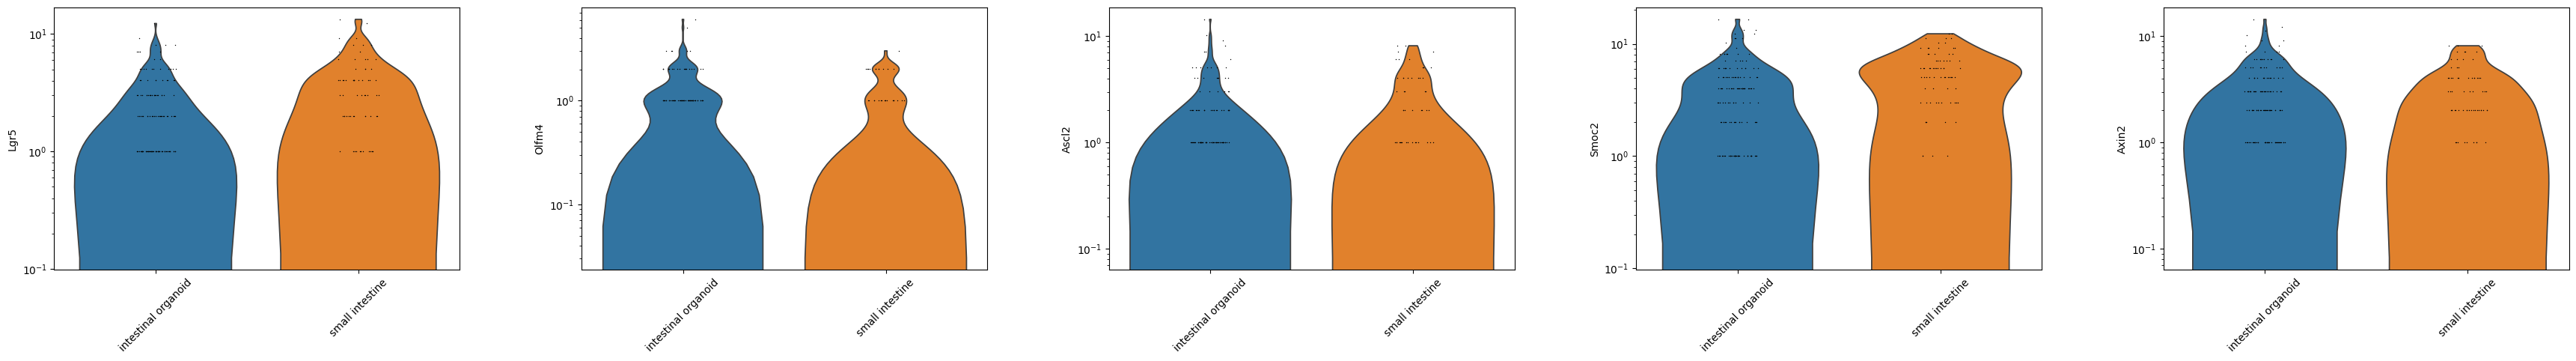

In [6]:
isc_markers = [g for g in ['Lgr5', 'Olfm4', 'Ascl2', 'Smoc2', 'Axin2'] if g in adata.var_names]
if isc_markers:
    sc.pl.violin(adata, isc_markers, groupby='tissue', rotation=45, log=True)

### Record provenance and save

In [7]:
timestamp = datetime.now().strftime('%d%m%Y_%H%M%S')
adata.uns['GSE'] = 'GSE62270'
adata.uns['publication'] = 'Grün D et al., Nature 525:251-255 (2015) — Single-cell mRNA sequencing reveals rare intestinal cell types (RaceID)'
adata.uns['genome_reference'] = 'mm9 (per Grün 2015 — exact assembly inferable from __chrN suffix on gene IDs)'
adata.uns['source_files'] = ['GSE62270_data_counts_Lgr5.txt', 'GSE62270_data_counts_Lgr5SC.txt', 'GSE62270_96BC.txt']
adata.uns['processing_history'] = {
    timestamp: 'AnnData created from 2 CEL-Seq plate count tables (96 primary intestine + 192 organoid cells); __chrN suffix stripped from gene IDs; lgr5_status=LGR5+ assigned uniformly; QC metrics computed; no filtering applied. | note: Counts are CEL-Seq RaceID-normalised floats, not raw integers. Two plates of organoid cells are distinguishable via the `plate` column (Lgr5SC1 vs Lgr5SC2).',
}

out_dir = 'data/LGR5_analysis'
os.makedirs(out_dir, exist_ok=True)
out_path = f'{out_dir}/gut_mm_GSE62270_AM_{timestamp}_raw.h5ad'
adata.write_h5ad(out_path)
print(out_path, adata.shape)

data/LGR5_analysis/gut_mm_GSE62270_AM_07052026_233253_raw.h5ad (288, 23630)
